<a href="https://colab.research.google.com/github/scelliot-cpu/Elliott_DSPN_26_FinalProject/blob/main/Elliott_DSPN_S26_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How Age and Reaction Time Influence Sensorimotor Adaptation


##Background
Sensorimotor adaptation is the process by which individuals adjust their movements in response to altered sensory feedback. In this dataset, participants completed a visuomotor rotation task where the cursor was rotated relative to hand movement.

This project investigates how individual differences in age and reaction time relate to motor adaptation. Understanding these relationships can provide insight into how learning and motor control change across development. This project uses data from *Large-scale citizen science reveals predictors of sensorimotor adaptation*. Participants completed a web-based visuomotor rotation task in which they made reaching movements to move a cursor towards a visual target on the screen (Figure 1). The cursor's projectory was systematically rotated away from their actual hand movement, forcing them to gradually adjust their movement to account for the error. Over repeated trials, researchers measured how well and how quickly participants adapted to this error, along with collecting basic demographic information through a survey.

###Figure 1: Schematic of the Sensorimotor Task

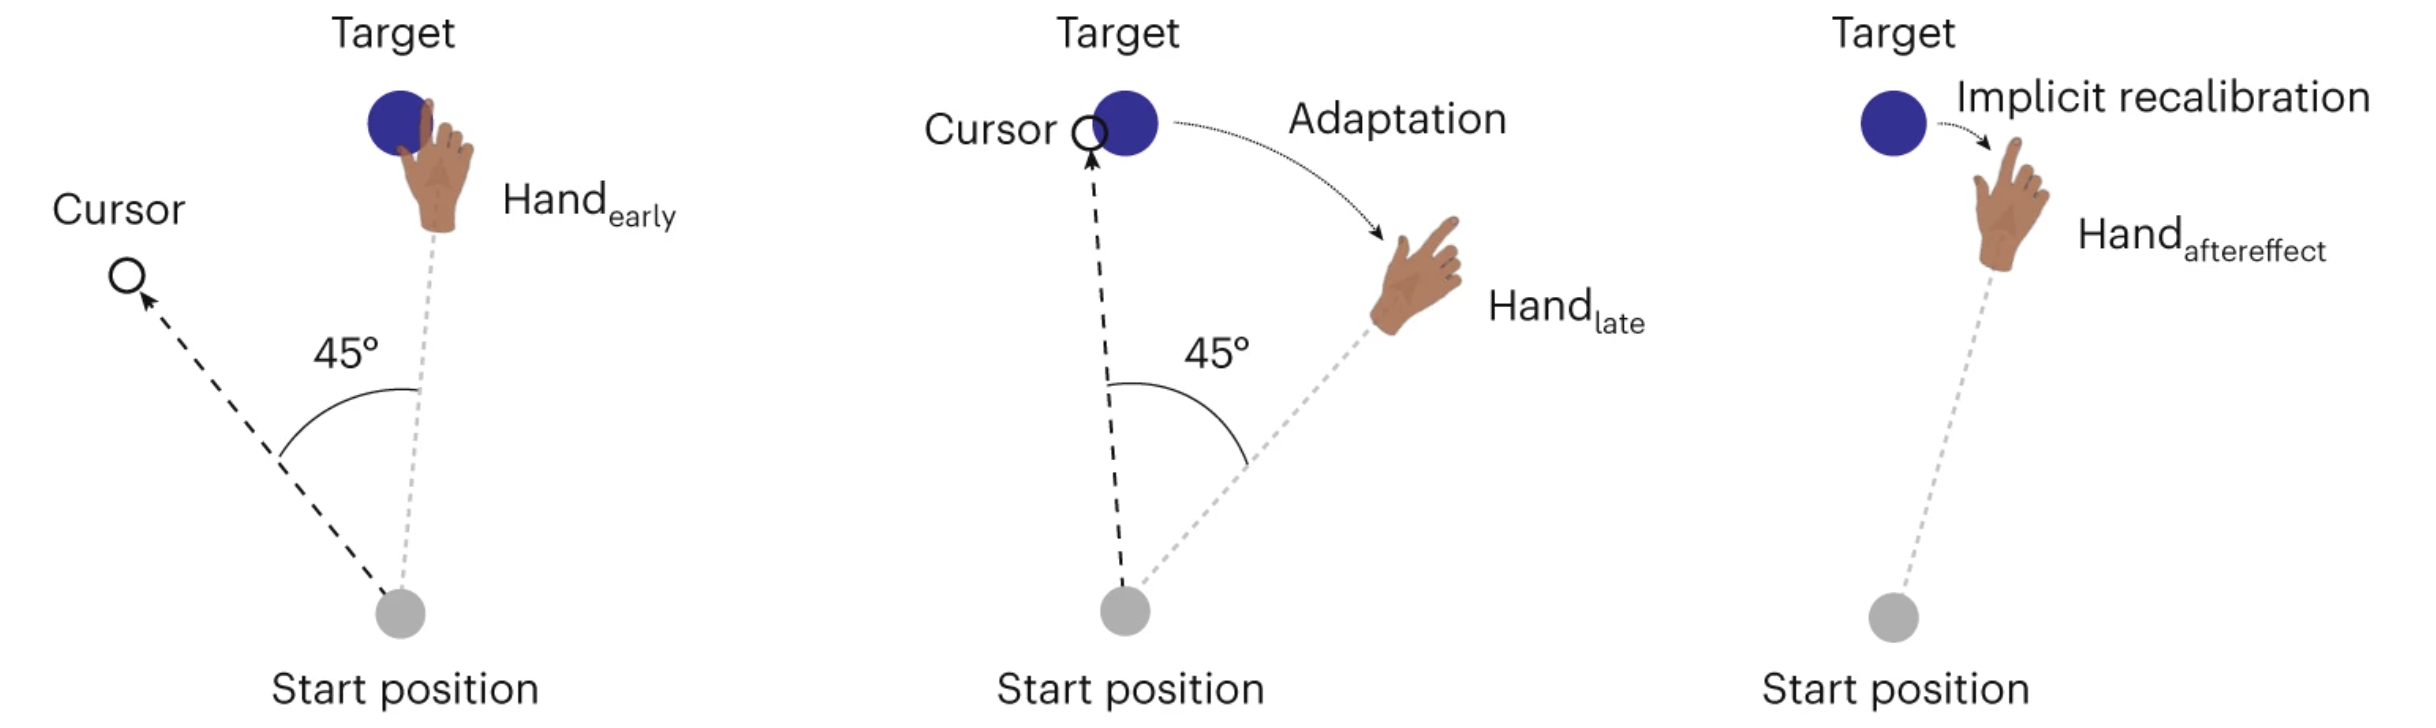

##Variables of Interest

**Subject ID:** Subject.ID

**Demographic Measures:**

*   **Sex**
*   **Age**

**Trial-Level Task Variables:**

*   TN: Trial Number
*   Block: Task Block
*   ST: Search Time
*   RT: Reaction Time
*   MT: Movement Time
*   ri: Size of Rotation








##Hypotheses
H1: Children will show reduced early motor adaptation relative to young adults.

H2: Children will show reduced late motor adaptation relative to young adults.

H3: Children will show smaller aftereffects than young adults.

H4: Children will have a slower reaction time than young adults.

##Data Plan Organization

###Data Architecture
The raw dataset is trial-level, meaning that each row corresponds to one trial from one participant. Each participant contributes multiple trials across baseline, adaptation, and aftereffect phases.

###Data Cleansing
1.   Define Developmental Groups: Child (<18) and Young Adults (18-30)
2.   Seperate trials into baseline, early adaptation, late adaptation, and aftereffect phases.
3. Aggregate trial-level data into participant-level summary tables for analysis.







In [1]:
install.packages(c("googledrive", "tidyverse", "ggplot2"))

library(googledrive)
library(tidyverse)
library(ggplot2)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
file_id <- "1o4Hgv1CyToFkHTmtSoyfyV3r2j9tLsrS"

url <- paste0("https://drive.google.com/uc?id=", file_id)

data <- read.csv(url)

head(data)

,TN,Subject.ID,ST,RT,MT,ti,ri,Group,CCW,numtar,⋯,screenheight,screenwidth,endtime,clumsy,seedisplay,videogames,major,Sleep,ComputerUsage,gameIndex
,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<lgl>,<int>,⋯,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>
1,1,02a12b38-eabd-4291-b58a-ca6fa0910470,2164,736,256,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
2,2,02a12b38-eabd-4291-b58a-ca6fa0910470,907,366,663,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
3,3,02a12b38-eabd-4291-b58a-ca6fa0910470,1101,298,308,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
4,4,02a12b38-eabd-4291-b58a-ca6fa0910470,992,294,39,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
5,5,02a12b38-eabd-4291-b58a-ca6fa0910470,2400,165,184,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
6,6,02a12b38-eabd-4291-b58a-ca6fa0910470,1469,96,217,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy


In [3]:
#Define Age Groups
library(dplyr)

clean_data <- data %>%
  mutate(Group = case_when(
  Age < 18 ~ "Child",
  Age >= 18 & Age <=30 ~ "YoungAdult"
  )) %>%
  filter(!is.na(Group))

In [4]:
#Define Adaptation Phases
clean_data <- clean_data %>%
  mutate(Phase = case_when(
    Block == 1 ~ "Baseline",
    Block == 2 ~ "Adaptation",
    Block == 3 ~ "Aftereffect",
    Block == 4 ~ "OppositeAdaptation",
  ))

clean_data <- clean_data %>%
  group_by(Subject.ID, Phase) %>%
  mutate(Trial_in_Phase = row_number()) %>%
  ungroup()

clean_data <- clean_data %>%
  mutate(Stage = case_when(
    Phase == "Adaptation" & Trial_in_Phase <= 10 ~ "Early Adaptation",
    Phase == "Adaptation" & Trial_in_Phase > 10 ~ "Late Adaptation",
    TRUE ~ Phase
  ))

  head(clean_data)

TN,Subject.ID,ST,RT,MT,ti,ri,Group,CCW,numtar,⋯,clumsy,seedisplay,videogames,major,Sleep,ComputerUsage,gameIndex,Phase,Trial_in_Phase,Stage
<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<lgl>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<chr>
1,02a12b38-eabd-4291-b58a-ca6fa0910470,2164,736,256,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,1,Baseline
2,02a12b38-eabd-4291-b58a-ca6fa0910470,907,366,663,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,2,Baseline
3,02a12b38-eabd-4291-b58a-ca6fa0910470,1101,298,308,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,3,Baseline
4,02a12b38-eabd-4291-b58a-ca6fa0910470,992,294,39,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,4,Baseline
5,02a12b38-eabd-4291-b58a-ca6fa0910470,2400,165,184,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,5,Baseline
6,02a12b38-eabd-4291-b58a-ca6fa0910470,1469,96,217,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,6,Baseline


##Statistical Analysis
This project includes three levels of analysis:

1. **Main Analysis:** compare children and young adults across early adaptation, late adaptation, and aftereffect phases
2. **Secondary Analysis:** compare children and young adults on baseline MT, ST, RT, and hand angle variability
3. **Explatory Analysis:** test whether demographic and behavioral measures predict motor variability in children

In [5]:
#Participant-Level Dataset
summary_data <- clean_data %>%
  filter(Stage %in% c("Early Adaptation", "Late Adaptation", "Aftereffect")) %>%
  group_by(Subject.ID, Group, Stage) %>%
  summarise(
    mean_MT = mean(MT, na.rm = TRUE),
    mean_RT = mean(RT, na.rm = TRUE),
    mean_ST = mean(ST, na.rm = TRUE),
    .groups = "drop"
  )

head(summary_data)

Subject.ID,Group,Stage,mean_MT,mean_RT,mean_ST
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Aftereffect,36.33333,303.8333,2567.333
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Early Adaptation,112.90000,327.6000,2153.700
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Late Adaptation,47.56818,170.5227,1954.512
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Aftereffect,62.33333,296.1667,1426.833
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Early Adaptation,58.50000,300.8889,2014.500
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Late Adaptation,58.84091,217.3864,1886.318


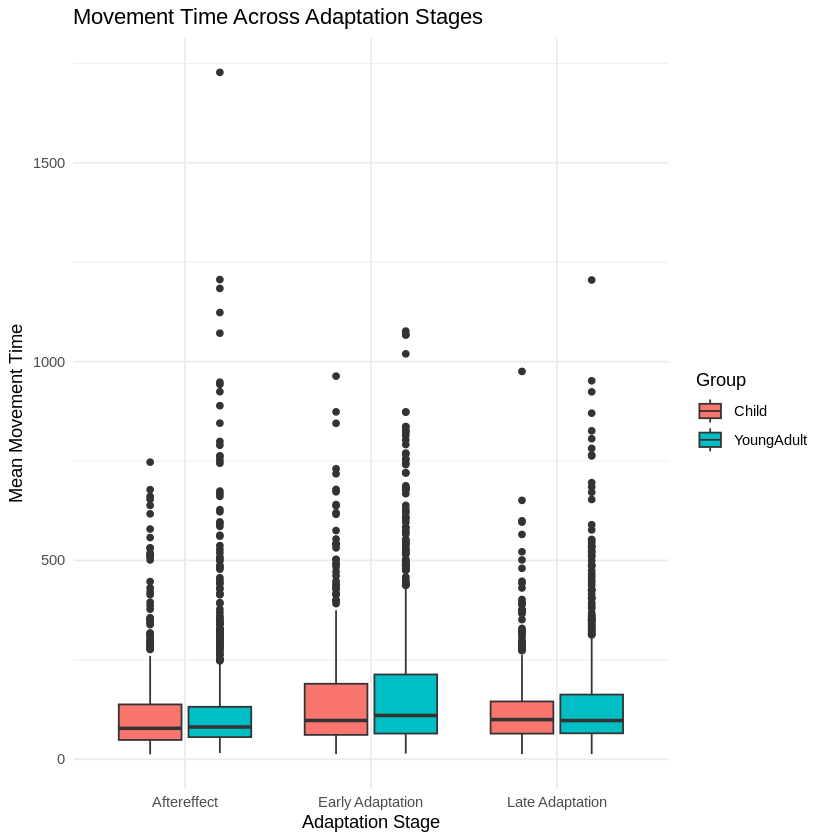

In [6]:
library(ggplot2)
ggplot(summary_data, aes(x = Stage, y = mean_MT, fill = Group)) +
  geom_boxplot() +
  theme_minimal() +
  labs(
    title = "Movement Time Across Adaptation Stages",
    x = "Adaptation Stage",
    y = "Mean Movement Time"
  )

In [7]:
model_mt <- lm(mean_MT ~ Group * Stage, data = summary_data)

summary(model_mt)


Call:
lm(formula = mean_MT ~ Group * Stage, data = summary_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-159.37  -79.09  -47.16   20.05 1598.30 

Coefficients:
                                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)                            121.431      7.021  17.294  < 2e-16 ***
GroupYoungAdult                          7.602      8.455   0.899 0.368625    
StageEarly Adaptation                   33.316      9.930   3.355 0.000801 ***
StageLate Adaptation                     7.699      9.930   0.775 0.438157    
GroupYoungAdult:StageEarly Adaptation   11.424     11.957   0.955 0.339397    
GroupYoungAdult:StageLate Adaptation     1.332     11.957   0.111 0.911272    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 144.2 on 4074 degrees of freedom
Multiple R-squared:  0.01659,	Adjusted R-squared:  0.01538 
F-statistic: 13.74 on 5 and 4074 DF,  p-value: 2.471e-13


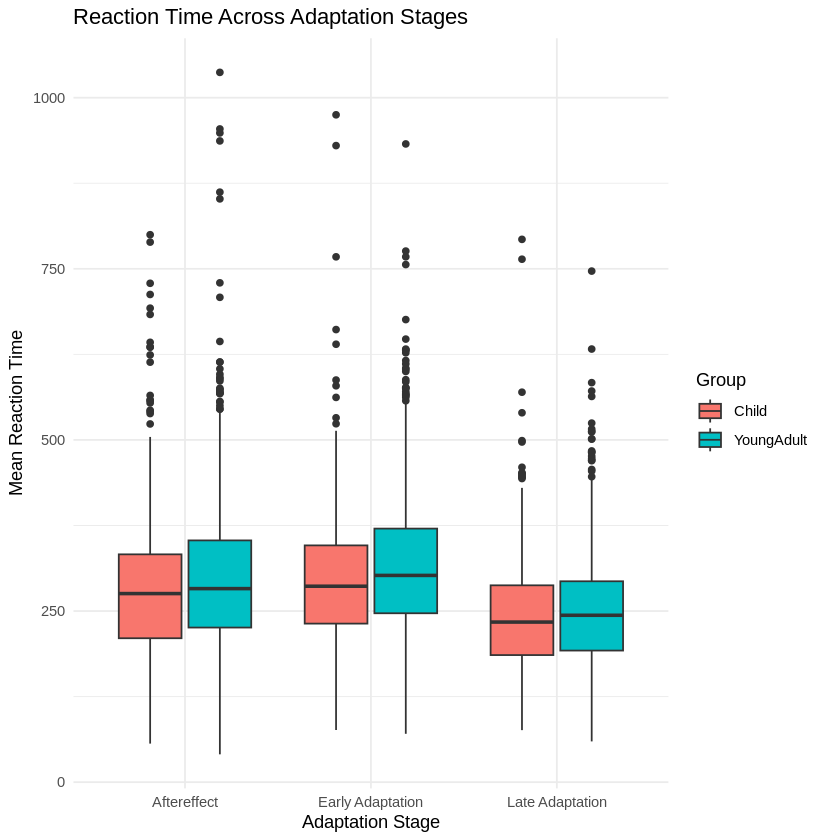

In [8]:
library(ggplot2)
ggplot(summary_data, aes(x = Stage, y = mean_RT, fill = Group)) +
  geom_boxplot() +
  theme_minimal() +
  labs(
    title = "Reaction Time Across Adaptation Stages",
    x = "Adaptation Stage",
    y = "Mean Reaction Time"
  )

In [9]:
model_rt <- lm(mean_RT ~ Group * Stage, data = summary_data)

summary(model_rt)


Call:
lm(formula = mean_RT ~ Group * Stage, data = summary_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-256.52  -66.21  -11.19   49.70  739.81 

Coefficients:
                                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)                            283.819      4.933  57.538  < 2e-16 ***
GroupYoungAdult                         13.369      5.940   2.251   0.0245 *  
StageEarly Adaptation                   12.480      6.976   1.789   0.0737 .  
StageLate Adaptation                   -39.052      6.976  -5.598 2.31e-08 ***
GroupYoungAdult:StageEarly Adaptation    5.536      8.400   0.659   0.5099    
GroupYoungAdult:StageLate Adaptation    -8.818      8.400  -1.050   0.2939    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 101.3 on 4074 degrees of freedom
Multiple R-squared:  0.06518,	Adjusted R-squared:  0.06403 
F-statistic: 56.81 on 5 and 4074 DF,  p-value: < 2.2e-16
